# Task 2: Heart Disease Predictive Modeling

This notebook develops a leak-free classifier for heart disease presence. It removes duplicate patient records *before* splitting, fits all preprocessing inside pipelines, compares three models, and tunes the selected ensemble without using the final test set.

> **Google Colab:** Upload `Task 2` to `MyDrive/Thiranex/Task 2`, then run every cell. The setup cell mounts Drive and discovers the folder automatically.


In [1]:
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q pandas numpy scikit-learn matplotlib seaborn joblib
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    candidates = [
        Path('/content/drive/MyDrive/Thiranex/Task 2'),
        Path('/content/drive/MyDrive/Task 2'),
        Path('/content/Task 2'),
    ]
    PROJECT_ROOT = next((path for path in candidates if path.exists()), None)
    if PROJECT_ROOT is None:
        raise FileNotFoundError('Upload Task 2 to MyDrive/Thiranex/Task 2 and rerun.')
else:
    PROJECT_ROOT = Path.cwd().resolve()
    if PROJECT_ROOT.name == 'notebooks':
        PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from data_cleaning import audit_dataset, run_cleaning_pipeline
from modeling import evaluate_model, feature_importance, save_model, train_and_compare, tune_random_forest
from visualization import create_diagnostics, plot_feature_importance

RAW_PATH = PROJECT_ROOT / 'data/raw/heart.csv'
CLEANED_PATH = PROJECT_ROOT / 'data/processed/task2_cleaned.csv'
FIGURES_DIR = PROJECT_ROOT / 'reports/figures'
MODEL_PATH = PROJECT_ROOT / 'models/tuned_random_forest.joblib'
print(f'Project root: {PROJECT_ROOT}')


C:\Users\Syed Imad Muzaffar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Project root: C:\Users\Syed Imad Muzaffar\Downloads\Thiranex\Task 2


## 1. Data Audit and Leakage-Safe Cleaning

The raw data have no nulls, but exact duplicate records must not appear across training and test sets. We remove them before the stratified split. Coded clinical variables are retained as categorical features later in the pipeline.


In [2]:
import pandas as pd

raw_df, df, audit, cleaning_log = run_cleaning_pipeline(RAW_PATH, CLEANED_PATH)
print('Raw shape:', audit['shape'])
print('Missing values:', sum(audit['missing_values'].values()))
print('Exact duplicates:', audit['duplicate_rows'])
print('Cleaning log:', cleaning_log)
print('Cleaned shape:', df.shape)
display(df.head())
display(pd.Series(audit['class_balance'], name='class proportion'))


Raw shape: (1025, 14)
Missing values: 0
Exact duplicates: 723
Cleaning log: {'duplicates_removed': 723, 'rows_after_cleaning': 302}
Cleaned shape: (302, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


0    0.486829
1    0.513171
Name: class proportion, dtype: float64

## 2. Baseline Model Comparison

An 80/20 stratified split is held out once. Logistic Regression provides an interpretable baseline; Random Forest and Gradient Boosting provide nonlinear ensemble comparisons. Metrics are calculated exclusively on the same holdout data.


In [3]:
comparison, fitted_models, X_train, X_test, y_train, y_test = train_and_compare(df)
print(f'Train observations: {len(X_train)} | Test observations: {len(X_test)}')
display(comparison.style.format({column: '{:.3f}' for column in comparison.columns if column != 'Model'}))


Train observations: 241 | Test observations: 61


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.836,0.848,0.848,0.848,0.905,0.923
1,Random Forest,0.787,0.812,0.788,0.800,0.876,0.896
2,Gradient Boosting,0.770,0.788,0.788,0.788,0.828,0.839


## 3. Hyperparameter Tuning

We tune Random Forest using five-fold stratified cross-validation on the training partition only, optimizing ROC-AUC. The untouched test partition is used after selection for an honest final estimate.


In [4]:
search = tune_random_forest(X_train, y_train)
best_model = search.best_estimator_
metrics, y_pred, y_probability = evaluate_model(best_model, X_test, y_test)

print('Best cross-validation ROC-AUC:', round(search.best_score_, 3))
print('Best parameters:', search.best_params_)
display(pd.Series(metrics, name='Tuned holdout score').to_frame().style.format('{:.3f}'))


Best cross-validation ROC-AUC: 0.917
Best parameters: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 500}


,Tuned holdout score
Accuracy,0.803
Precision,0.818
Recall,0.818
F1,0.818
ROC-AUC,0.884
PR-AUC,0.902


## 4. Diagnostics and Feature Importance

ROC-AUC captures ranking discrimination, while the precision-recall curve is useful for viewing positive-class performance. The confusion matrix exposes false negatives, which should be reviewed carefully in a clinical setting. Impurity-based feature importance is descriptive, not causal.


,feature,importance
7,categorical__cp_0,0.143070
28,categorical__thal_2,0.113542
21,categorical__ca_0,0.093937
3,numeric__thalach,0.091905
29,categorical__thal_3,0.081340
4,numeric__oldpeak,0.074608
17,categorical__exang_1,0.056488
16,categorical__exang_0,0.054764
0,numeric__age,0.046443
2,numeric__chol,0.040337


01_confusion_matrix.png


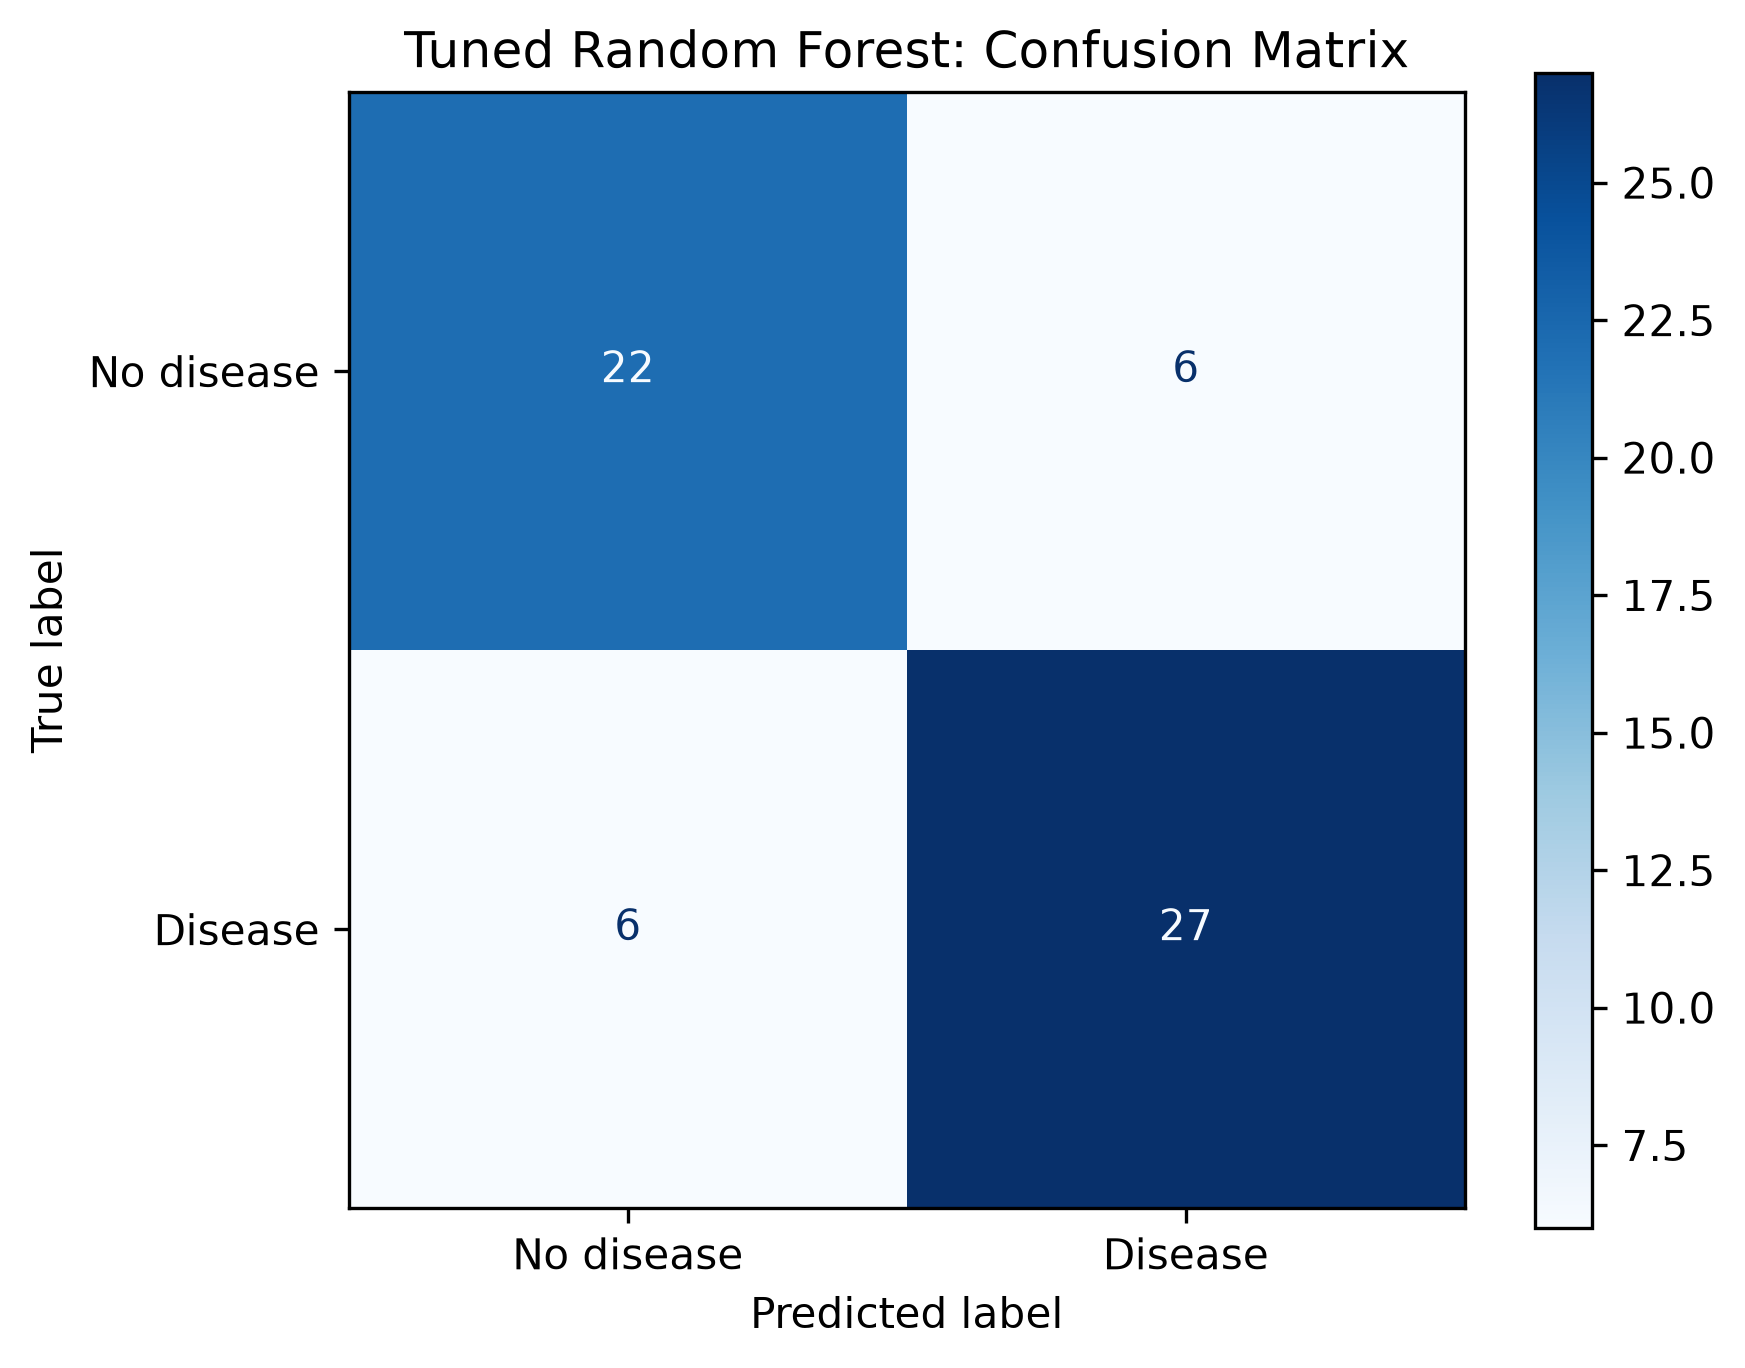

02_roc_curve.png


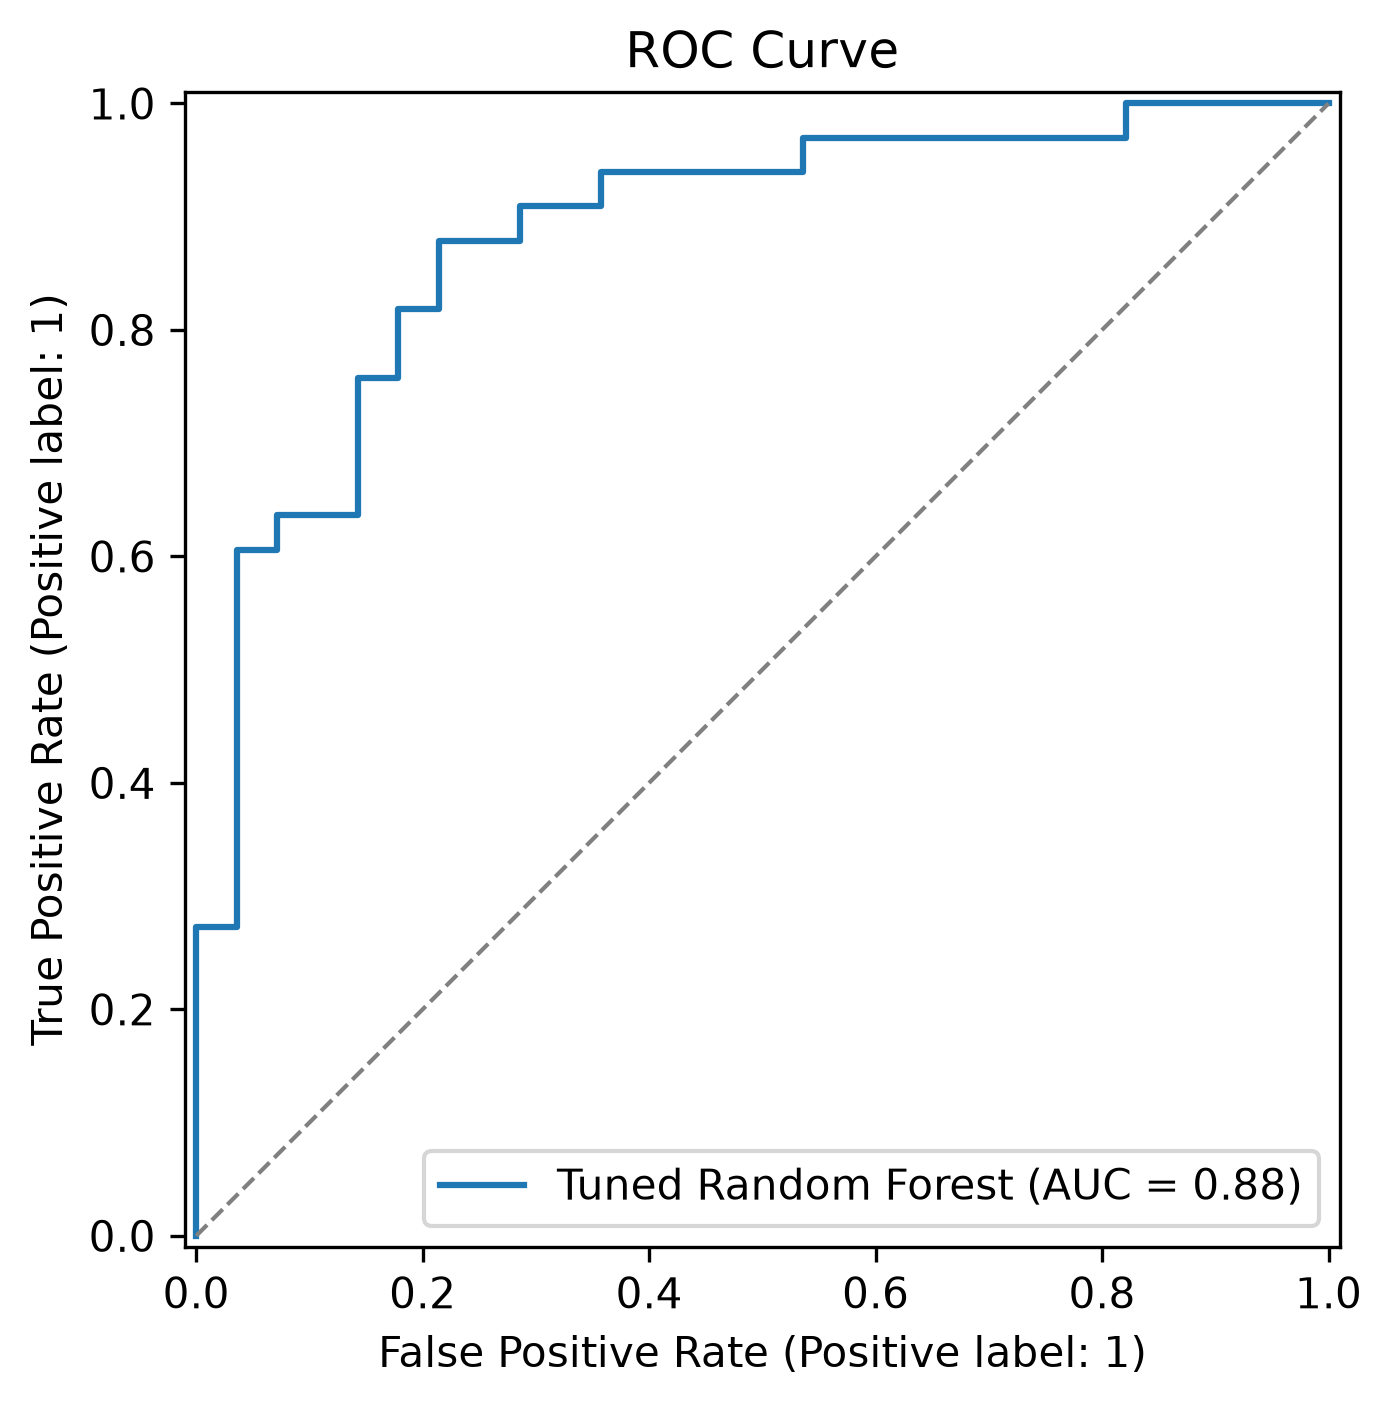

03_precision_recall_curve.png


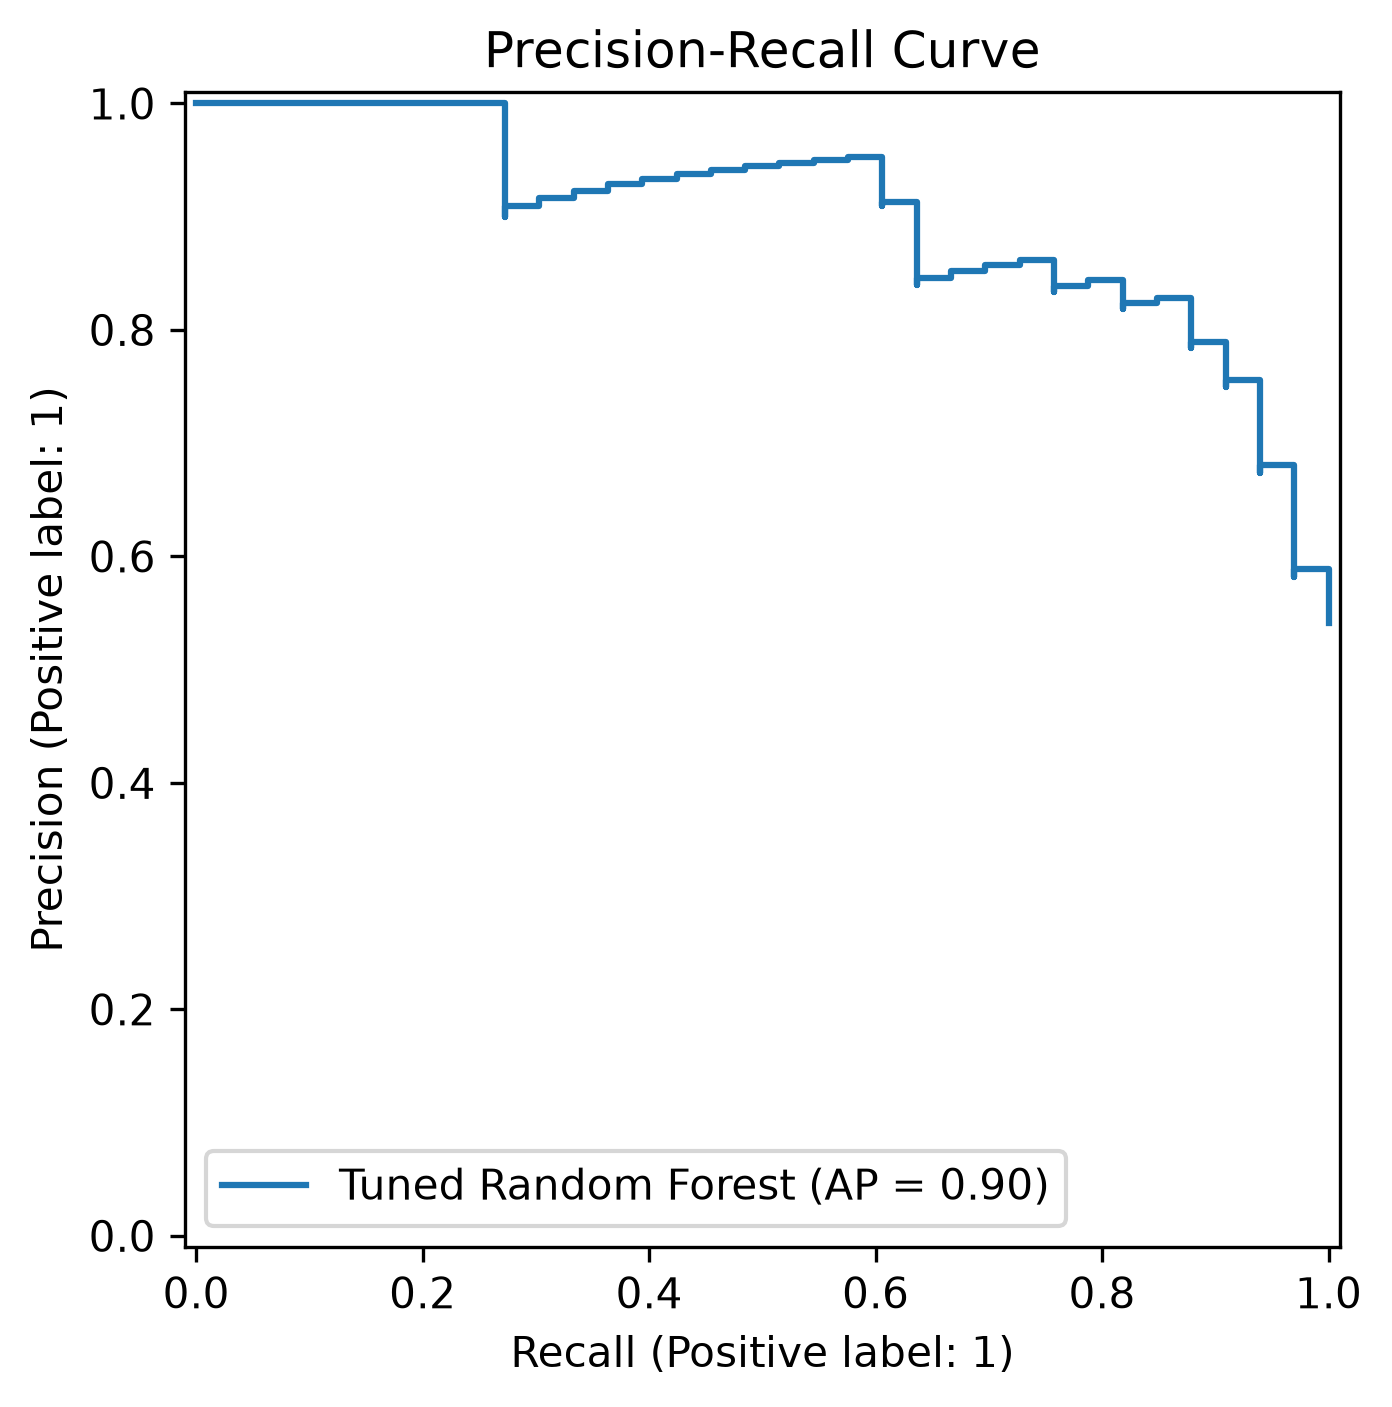

04_feature_importance.png


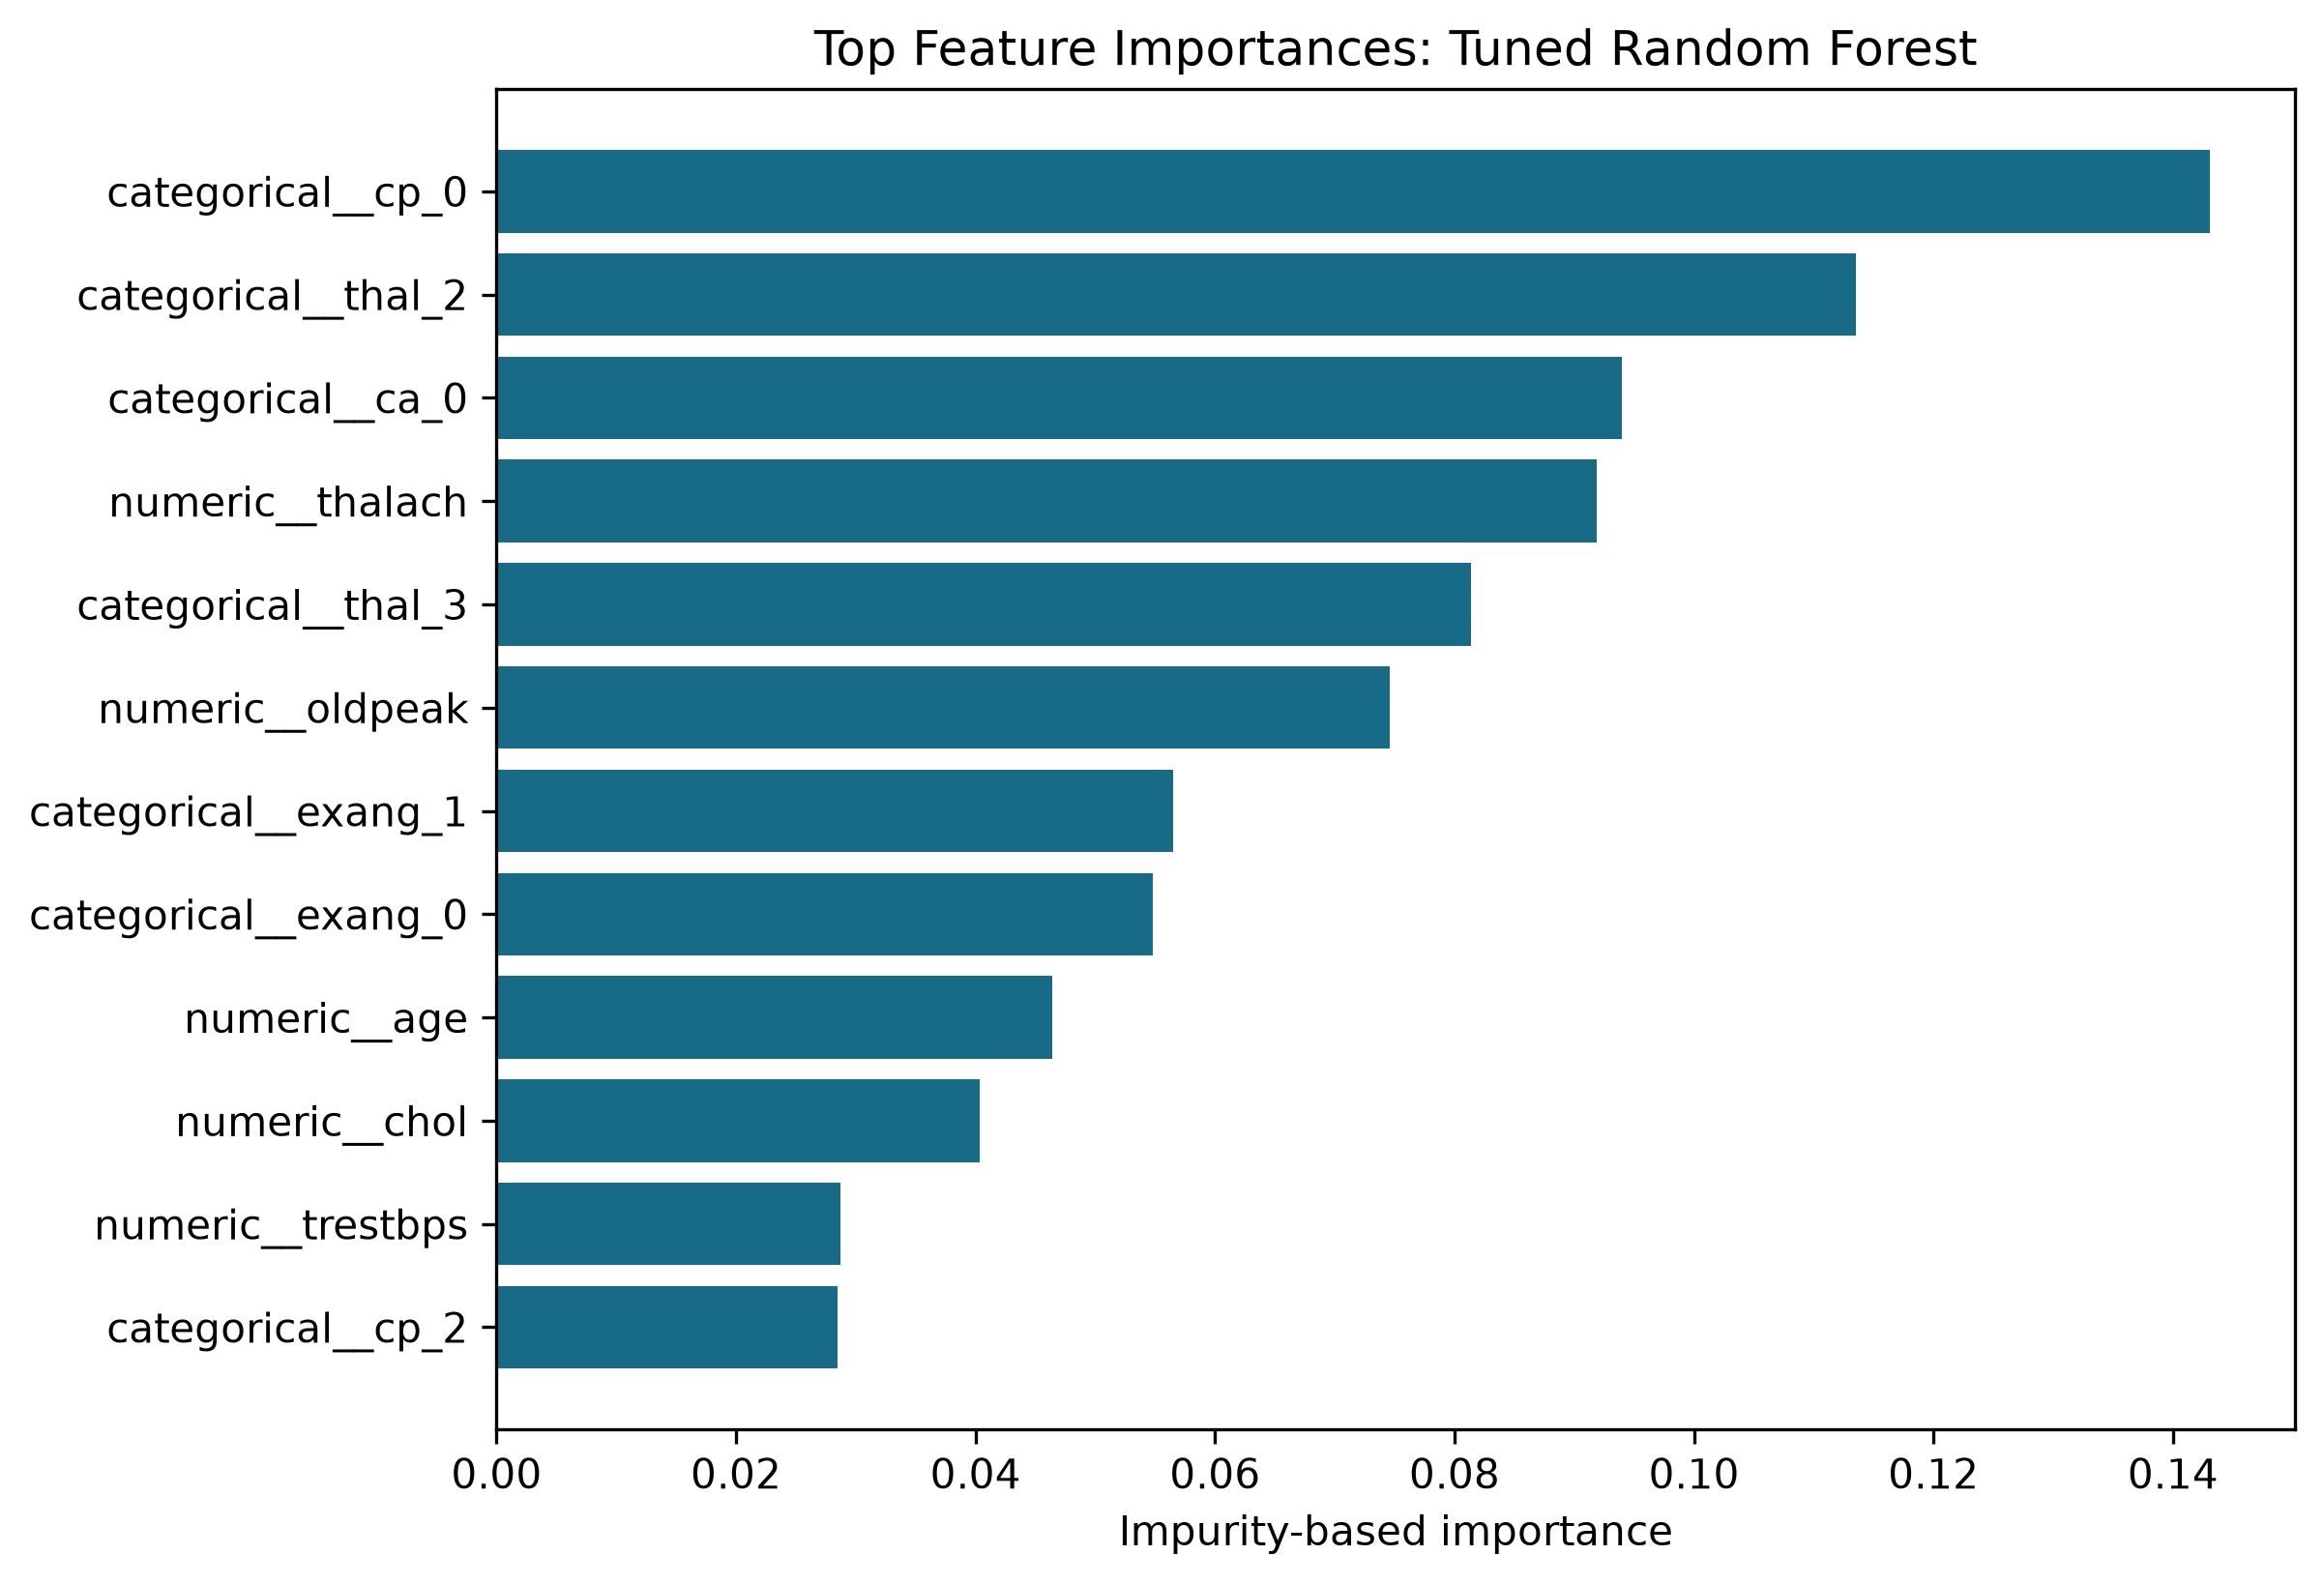

Full fitted pipeline saved to: C:\Users\Syed Imad Muzaffar\Downloads\Thiranex\Task 2\models\tuned_random_forest.joblib


In [5]:
from IPython.display import Image, display

importance = feature_importance(best_model)
figure_paths = create_diagnostics(best_model, X_test, y_test, FIGURES_DIR)
figure_paths.append(plot_feature_importance(importance, FIGURES_DIR))
save_model(best_model, MODEL_PATH)

display(importance.head(12))
for path in figure_paths:
    print(path.name)
    display(Image(filename=str(path)))
print(f'Full fitted pipeline saved to: {MODEL_PATH}')


## 5. Conclusions and Responsible Use

The comparison table and tuned holdout metrics above are the project’s final reported estimates. Use recall, false negatives, ROC-AUC, and PR-AUC together when discussing a deployment threshold; do not rely on accuracy alone. This is a portfolio exercise, not a clinical decision-support system.
